## **Data Science Internship – Task 3**

# **Titanic Dataset: Mini Exploratory Data Analysis (EDA)**

### **STEP 1: Load Dataset**

In [4]:
import pandas as pd
df = pd.read_csv(r"C:\Users\jprat\Downloads\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **STEP 2: Clean dataset**

**Aim:** To check missing values.

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**i) Fill Missing Age with Mean**

**Aim:** To handle missing values in the Age column by replacing them with the mean value.

In [12]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Result:** The missing values in the Age column were successfully filled using the mean, ensuring no missing data remains in this column.

**ii) Drop Irrelevant Column (Cabin)**

**Aim:** To remove the Cabin column due to a large number of missing values and low relevance.

In [19]:
df.drop('Cabin', axis=1, inplace=True)

In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

**Result:** The Cabin column was removed from the dataset as it contained a large number of missing values.

### **STEP 3: Analysis Questions**

**i) Survival Rate by Age Group**

**Aim:** To analyze the survival rate across different age groups.

In [27]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100])

df.groupby('AgeGroup')['Survived'].mean()

C:\Users\jprat\AppData\Local\Temp\ipykernel_13272\1061790251.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


AgeGroup
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.353271
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

**Result:** Survival rates vary across different age groups, with younger passengers generally showing higher survival rates.

**ii) Survival Rate by Embarkation Port**

**Aim:** To examine how embarkation port affected survival rates.

In [32]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

**Result:** Passengers who boarded from Cherbourg (C) had the highest survival rate, followed by Queenstown (Q), while passengers from Southampton (S) had the lowest survival rate. This indicates that the embarkation port influenced survival outcomes.

**iii) Survival Rate by Family Size**

**Aim:** To analyze the effect of family size on survival.

In [37]:
df['FamilySize'] = df['SibSp'] + df['Parch']

df.groupby('FamilySize')['Survived'].mean()

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

**Result:** The survival rate varies significantly with family size. Passengers with small family sizes (1–3 members) had the highest survival rates, while those traveling alone or in large families had lower chances of survival. This indicates that moderate family size positively influenced survival.

### **STEP 3: Visualizations**

**i) Age Distribution (Histogram)**

**Aim:** To visualize the distribution of passenger ages.

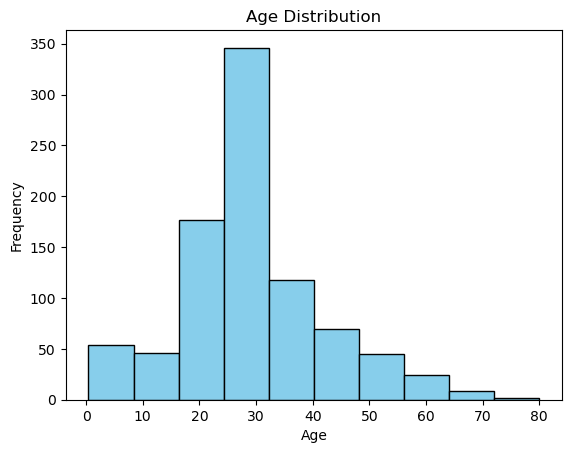

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Age'], bins=10, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Result:** The graph shows that most passengers were young to middle-aged, and very few were elderly.

**ii) Heatmap of Correlations**

**Aim:** To identify relationships between numerical variables in the dataset.

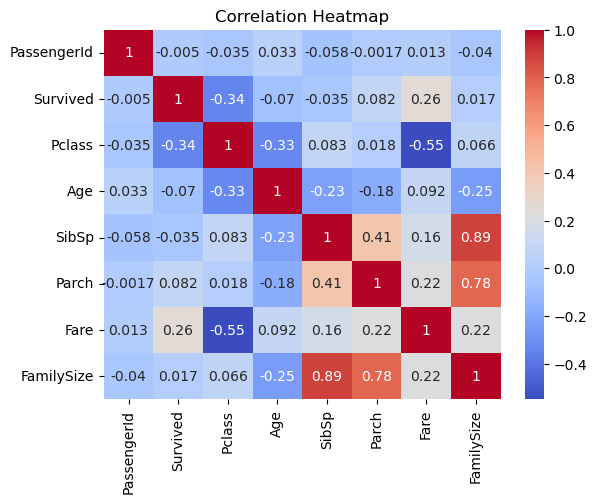

In [47]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Result:** The graph shows that Fare, FamilySize and Parch are positively related to survival, meaning higher values are associated with better survival chances. Pclass is negatively related to survival, indicating that passengers in lower classes had lower chances of survival.

**iii) Survival by Family Size (Bar Plot)**

**Aim:** To visualize how family size influences survival rates.

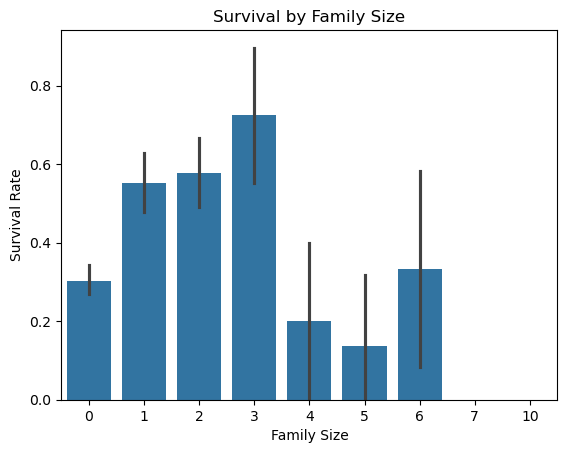

In [52]:
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

**Result:** The graph shows that passengers with small to moderate family sizes had higher survival rates, while those traveling alone or in large families had lower survival chances.

**Overall Conclusion:** 

i) The analysis shows that survival on the Titanic was influenced by multiple factors such as age, family size, fare and passenger class.

ii) Passengers with higher fares and small to moderate family sizes had better chances of survival.

iii) Passengers in lower classes had lower survival rates compared to those in higher classes.

iv) Most passengers were young, which influenced the overall survival pattern.